In [51]:
!pip install langgraph-supervisor langchain-openai


   -------------------- ------------------- 1/2 [langgraph-supervisor]
   ---------------------------------------- 2/2 [langgraph-supervisor]



In [1]:
import pandas as pd
import dspy
from langgraph.graph import StateGraph, START, END
from ollama import Client, generate
from tqdm.auto import tqdm
tqdm.pandas()

import sys
sys.path.append("../utils")

import graph_1
import graph_2
import graph_3
import graph_4

c:\Users\asus\miniconda3\envs\absa_val\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [31]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

pd.set_option(
    "display.max_colwidth", 12,
    "display.max_rows", 20,
    "display.max_columns", 50,
    "display.precision", 4
)
plt.style.use('../utils/MyStyle.txt')
cm = 1/2.54
palette = ["#3F3517",  '#CE2E31', '#C96F6B', '#CCA464', '#F8D768', '#F0DCD4']

In [2]:
# MODEL = "phi4:14b"
API_KEY = ""
API_BASE = "http://localhost:11434"

# API_BASE = "http://localhost:52625"
MODEL = "llama3.1:8b"

In [3]:
lm = dspy.LM(f"ollama_chat/{MODEL}", api_base=API_BASE, api_key=API_KEY)
dspy.configure(lm=lm)

### Pipeline prompts
- aspect term extraction (ATE), which identifies the features or aspects being discussed (e.g., "food"), 
- opinion term extraction (OTE), which finds the words expressing an opinion (e.g., "delicious"), 
- aspect-level sentiment classification (ASC)

In [5]:
graph = StateGraph(graph_1.ABSAState)

graph.add_node("agent_initiation", graph_1.node_initiation)
graph.add_node("ATE", graph_1.node_ate)
graph.add_node("ATE_supervision", graph_1.node_ate_supervision)

graph.add_edge("agent_initiation", "ATE")
graph.add_edge("ATE", "ATE_supervision")

graph.add_node("OTE", graph_1.node_ote)
graph.add_node("OTE_supervision", graph_1.node_ote_supervision)

graph.add_conditional_edges(
    "ATE_supervision",    # Source node
    graph_1.should_continue_ate, # Action
    {
        "ATE": "ATE",  
        "OTE": "OTE"         
    })
graph.add_edge("OTE", "OTE_supervision")

graph.add_node("ALSC", graph_1.node_alsc)
graph.add_node("ALSC_supervision", graph_1.node_alsc_supervision)

graph.add_conditional_edges(
    "OTE_supervision",     # Source node
    graph_1.should_continue_ote, # Action
    {
        "OTE": "OTE",  
        "ALSC": "ALSC"          
    })
graph.add_edge("ALSC", "ALSC_supervision")


graph.add_node("SA", graph_1.node_sa)
graph.add_node("SA_supervision", graph_1.node_sa_supervision)

graph.add_conditional_edges(
    "ALSC_supervision",     # Source node
    graph_1.should_continue_alsc, # Action
    {
        "ALSC": "ALSC",
        "END": END
    })
graph.add_edge("agent_initiation", "SA")
graph.add_edge("SA", "SA_supervision")
graph.add_conditional_edges(
    "SA_supervision",     # Source node
    graph_1.should_continue_sa, # Action
    {
        "SA": "SA",
        "END": END 
    })

graph.set_entry_point("agent_initiation")

app = graph.compile()

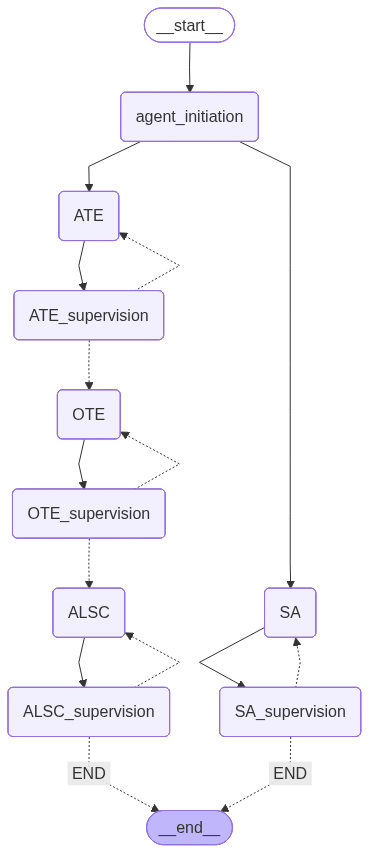

In [6]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
def run_absa_for_review(review_text: str):
    """Run your ABSA LangGraph pipeline on a single review."""
    try:
        # Create the initial state dynamically for each review
        state = graph_1.ABSAState(
            review = review_text,
            ate_agent = dspy.ChainOfThought(graph_1.ATE_Do),
            ate_supervision_agent = dspy.ChainOfThought(graph_1.ATE_Supervise),
            aspects = [],
            aspects_decision = "",
            aspects_rationale = "",
            aspects_counter = 0,

            ote_agent = dspy.ChainOfThought(graph_1.OTE_Do),
            ote_supervision_agent = dspy.ChainOfThought(graph_1.OTE_Supervise),
            opinions = [],
            opinions_decision = "",
            opinions_rationale = "",
            opinions_counter = 0,

            alsc_agent = dspy.ChainOfThought(graph_1.ALSC_Do),
            alsc_supervision_agent = dspy.ChainOfThought(graph_1.ALSC_Supervise),
            sentiments = [],
            sentiments_decision = "",
            sentiments_rationale = "",
            sentiments_counter = 0,

            sa_agent = dspy.ChainOfThought(graph_1.Overall_Do),
            sa_supervision_agent = dspy.ChainOfThought(graph_1.Overall_Supervise),
            overall_sentiment = "",
            overall_sentiment_decision = "",
            overall_sentiment_rationale = "",
            overall_sentiment_counter = 0,
        )

        result = app.invoke(state, {"recursion_limit": 100})

        return {
            "aspects": result.get("aspects", []),
            "aspects_decision": result.get("aspects_decision", ""),
            "opinions": result.get("opinions", []),
            "opinions_decision": result.get("opinions_decision", ""),
            "sentiments": result.get("sentiments", []),
            "sentiments_decision": result.get("sentiments_decision", ""),
            "overall_sentiment": result.get("overall_sentiment", ""),
            "overall_sentiment_decision": result.get("overall_sentiment_decision", ""),
        }

    except Exception as e:
        print(f"Error for review: {review_text[:25]}... -> {e}")
        return {
            "aspects": [],
            "aspects_decision": "",
            "opinions": [],
            "opinions_decision": "",
            "sentiments": [],
            "sentiments_decision": "",
            "overall_sentiment": "error",
            "overall_sentiment_decision": "",
        }

In [16]:
df = pd.read_excel('../data/1000_annotated_sample_final.xlsx')
df = df.drop(columns=(['Unnamed: 0', 'flag']))
df.shape

(1000, 12)

In [49]:
# res = run_absa_for_review(review_text=df.loc[1, 'text'])

In [50]:
# res

In [11]:
df["absa_results"] = df["text"].progress_apply(run_absa_for_review)

# Optionally extract nested parts into their own columns
df["aspects"] = df["absa_results"].apply(lambda x: x["aspects"])
df["opinions"] = df["absa_results"].apply(lambda x: x["opinions"])
df["sentiments"] = df["absa_results"].apply(lambda x: x["sentiments"])
df["overall_sentiment"] = df["absa_results"].apply(lambda x: x["overall_sentiment"])

  0%|          | 0/1000 [00:00<?, ?it/s]

node_initiation


  0%|          | 2/1000 [00:00<03:54,  4.25it/s]

node_initiation


  0%|          | 3/1000 [00:41<4:44:26, 17.12s/it]

node_initiation


  0%|          | 4/1000 [01:34<8:30:35, 30.76s/it]

node_initiation


  0%|          | 4/1000 [02:04<8:35:59, 31.08s/it]


KeyboardInterrupt: 

In [ ]:
df.to_excel('1000_annotated_sample_final_graph_1.xlsx')

### NLP feed + Pipeline
feed the result of NLP as the imput of LLM

In [4]:
graph = StateGraph(graph_2.ABSAState)

graph.add_node("agent_initiation", graph_2.node_initiation)
graph.add_node("NLP_processing", graph_2.node_nlp_extract_pairs)
graph.add_node("ATE", graph_2.node_ate)
graph.add_node("ATE_supervision", graph_2.node_ate_supervision)

graph.add_edge("agent_initiation", "NLP_processing")
graph.add_edge("NLP_processing", "ATE")
graph.add_edge("ATE", "ATE_supervision")

graph.add_node("OTE", graph_2.node_ote)
graph.add_node("OTE_supervision", graph_2.node_ote_supervision)

graph.add_conditional_edges(
    "ATE_supervision",    # Source node
    graph_2.should_continue_ate, # Action
    {
        "ATE": "ATE",  
        "OTE": "OTE"         
    })
graph.add_edge("OTE", "OTE_supervision")

graph.add_node("ALSC", graph_2.node_alsc)
graph.add_node("ALSC_supervision", graph_2.node_alsc_supervision)

graph.add_conditional_edges(
    "OTE_supervision",     # Source node
    graph_2.should_continue_ote, # Action
    {
        "OTE": "OTE",  
        "ALSC": "ALSC"         
    })
graph.add_edge("ALSC", "ALSC_supervision")



graph.add_node("SA", graph_2.node_sa)
graph.add_node("SA_supervision", graph_2.node_sa_supervision)
graph.add_edge("agent_initiation", "SA")

graph.add_conditional_edges(
    "ALSC_supervision",     # Source node
    graph_2.should_continue_alsc, # Action
    {
        "ALSC": "ALSC",
        "END": END
    })
graph.add_edge("SA", "SA_supervision")

graph.add_conditional_edges(
    "SA_supervision",     # Source node
    graph_2.should_continue_sa, # Action
    {
        "SA": "SA",
        "END": END 
    })

graph.set_entry_point("agent_initiation")

app = graph.compile()

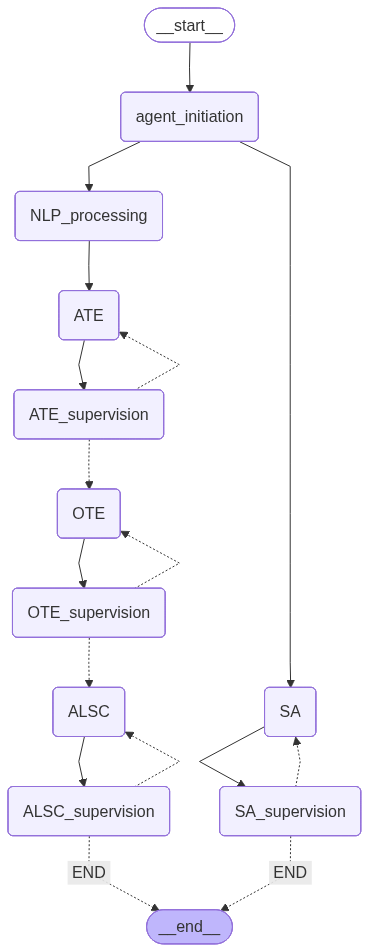

In [5]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
def run_absa_for_review(review_text: str, nlp_absa_fields: str):
    """Run your ABSA LangGraph pipeline on a single review."""
    try:
        # Create the initial state dynamically for each review
        state = graph_2.ABSAState(
            review = review_text,
            nlp_absa_fields = nlp_absa_fields,
            ate_agent = dspy.ChainOfThought(graph_2.ATE_Do),
            ate_supervision_agent = dspy.ChainOfThought(graph_2.ATE_Supervise),
            aspects = [],
            aspects_decision = "",
            aspects_rationale = "",
            aspects_counter = 0,

            ote_agent = dspy.ChainOfThought(graph_2.OTE_Do),
            ote_supervision_agent = dspy.ChainOfThought(graph_2.OTE_Supervise),
            opinions = [],
            opinions_decision = "",
            opinions_rationale = "",
            opinions_counter = 0,

            alsc_agent = dspy.ChainOfThought(graph_2.ALSC_Do),
            alsc_supervision_agent = dspy.ChainOfThought(graph_2.ALSC_Supervise),
            sentiments = [],
            sentiments_decision = "",
            sentiments_rationale = "",
            sentiments_counter = 0,

            sa_agent = dspy.ChainOfThought(graph_2.Overall_Do),
            sa_supervision_agent = dspy.ChainOfThought(graph_2.Overall_Supervise),
            overall_sentiment = "",
            overall_sentiment_decision = "",
            overall_sentiment_rationale = "",
            overall_sentiment_counter = 0,
        )

        result = app.invoke(state, {"recursion_limit": 100})

        return {
            "aspects": result.get("aspects", []),
            "aspects_decision": result.get("aspects_decision", ""),
            "opinions": result.get("opinions", []),
            "opinions_decision": result.get("opinions_decision", ""),
            "sentiments": result.get("sentiments", []),
            "sentiments_decision": result.get("sentiments_decision", ""),
            "overall_sentiment": result.get("overall_sentiment", ""),
            "overall_sentiment_decision": result.get("overall_sentiment_decision", ""),
        }

    except Exception as e:
        print(f"Error for review: {review_text[:25]}... -> {e}")
        return {
            "aspects": [],
            "aspects_decision": "",
            "opinions": [],
            "opinions_decision": "",
            "sentiments": [],
            "sentiments_decision": "",
            "overall_sentiment": "error",
            "overall_sentiment_decision": "",
        }

In [7]:
df2 = pd.read_excel('../data/1000_annotated_sample_final.xlsx')
df2 = df2.drop(columns=(['Unnamed: 0', 'flag']))
df2.shape

(1000, 12)

In [ ]:
# res2 = run_absa_for_review(review_text=df2.loc[0, 'text'], nlp_absa_fields=df2.loc[0,'atepc_json'])

node_initiation


In [ ]:
# res2

{'aspects': ['team'],
 'aspects_decision': 'revise',
 'opinions': [{'aspect': 'team', 'opinion': 'useless'},
  {'aspect': 'team', 'opinion': 'overpromises'}],
 'opinions_decision': 'revise',
 'sentiments': [{'aspect': 'team', 'opinion': '', 'sentiment': 'negative'},
  {'aspect': 'team', 'opinion': 'useless', 'sentiment': 'negative'},
  {'aspect': 'team', 'opinion': 'overpromises', 'sentiment': 'negative'}],
 'sentiments_decision': 'revise',
 'overall_sentiment': 'negative',
 'overall_sentiment_decision': 'revise'}

In [8]:
df2["absa_results"] = df2.progress_apply(func= lambda row: run_absa_for_review(row["text"], row["atepc_json"]),
                                         axis=1)

# Optionally extract nested parts into their own columns
df2["aspects"] = df2["absa_results"].apply(lambda x: x["aspects"])
df2["opinions"] = df2["absa_results"].apply(lambda x: x["opinions"])
df2["sentiments"] = df2["absa_results"].apply(lambda x: x["sentiments"])
df2["overall_sentiment"] = df2["absa_results"].apply(lambda x: x["overall_sentiment"])

  0%|          | 0/1000 [00:00<?, ?it/s]

node_initiation


  0%|          | 2/1000 [00:00<07:53,  2.11it/s]

node_initiation


  0%|          | 3/1000 [01:09<8:00:38, 28.93s/it]

...

100%|█████████▉| 999/1000 [12:08:55<00:50, 50.58s/it]

node_initiation


100%|██████████| 1000/1000 [12:09:43<00:00, 49.82s/it]

node_initiation


100%|██████████| 1000/1000 [12:11:02<00:00, 43.86s/it]


In [9]:
df2.to_excel('1000_annotated_sample_final_graph_2.xlsx')

### NLP feed

In [10]:
graph = StateGraph(state_schema=graph_3.ABSAState)

graph.add_node("agent_initiation", graph_3.node_initiation)
graph.add_node("NLP_processing", graph_3.node_nlp_extract_pairs)

graph.add_node("ABSA_supervision", graph_3.node_absa_supervision)
graph.add_node("ABSA", graph_3.node_absa)

graph.add_node("SA", graph_3.node_sa)
graph.add_node("SA_supervision", graph_3.node_sa_supervision)

graph.set_entry_point("agent_initiation")
graph.add_edge("agent_initiation", "NLP_processing")
graph.add_edge("NLP_processing", "ABSA_supervision")



graph.add_conditional_edges(
    "ABSA_supervision",    # Source node
    graph_3.should_continue_absa, # Action
    {
        "ABSA": "ABSA",  
        "END": END         
    })
graph.add_edge("ABSA", "ABSA_supervision")

graph.add_edge("agent_initiation", "SA")
graph.add_edge("SA", "SA_supervision")
graph.add_conditional_edges(
    "SA_supervision",     # Source node
    graph_3.should_continue_sa, # Action
    {
        "SA": "SA",
        "END": END 
    })


app = graph.compile()

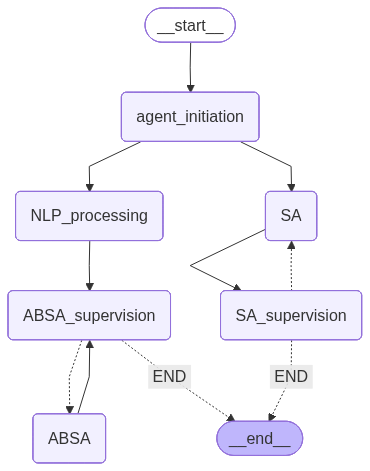

In [11]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
def run_absa_for_review(review_text: str, nlp_absa_fields: str):
    """Run your ABSA LangGraph pipeline on a single review."""
    try:
        # Create the initial state dynamically for each review
        state = graph_3.ABSAState(
            review = review_text,
            nlp_absa_fields = nlp_absa_fields,
            absa_agent = dspy.ChainOfThought(graph_3.ABSA_Do),
            absa_supervision_agent = dspy.ChainOfThought(graph_3.ABSA_Supervise),
            absa_fields = [],
            absa_decision = "",
            absa_fields_rationale = "",
            absa_fields_counter = 0,


            sa_agent = dspy.ChainOfThought(graph_3.Overall_Do),
            sa_supervision_agent = dspy.ChainOfThought(graph_3.Overall_Supervise),
            overall_sentiment = "",
            overall_sentiment_decision = "",
            overall_sentiment_rationale = "",
            overall_sentiment_counter = 0,
        )

        # Run the graph
        result = app.invoke(state, {"recursion_limit": 100})

        # Extract only the relevant outputs
        return {
            "absa_fields": result.get("absa_fields", []),
            "overall_sentiment": result.get("overall_sentiment", ""),
            "absa_decision": result.get("absa_decision", ""),
        }

    except Exception as e:
        print(f"Error for review: {review_text[:25]}... -> {e}")
        return {
            "absa_fields": [],
            "overall_sentiment": "error",
            "absa_decision": "",
        }

In [14]:
df3 = pd.read_excel('../data/1000_annotated_sample_final.xlsx')
df3 = df3.drop(columns=(['Unnamed: 0', 'flag']))
df3.shape

(1000, 12)

In [45]:
# res3 = run_absa_for_review(review_text=df3.loc[0, 'text'], nlp_absa_fields=df3.loc[0,'atepc_json'])

In [46]:
# res3

In [11]:
df3["absa_results"] = df3.progress_apply(func= lambda row: run_absa_for_review(row["text"], row["atepc_json"]),
                                         axis=1)

df3["absa_fields"] = df3["absa_results"].apply(lambda x: x["absa_fields"])
df3["overall_sentiment"] = df3["absa_results"].apply(lambda x: x["overall_sentiment"])

  0%|          | 0/1000 [00:00<?, ?it/s]

node_initiation
node_initiation


  0%|          | 3/1000 [00:19<1:46:59,  6.44s/it]

node_initiation


  0%|          | 4/1000 [00:33<2:26:29,  8.83s/it]

...

100%|█████████▉| 999/1000 [4:12:06<00:16, 16.34s/it]

node_initiation


100%|██████████| 1000/1000 [4:12:19<00:00, 15.35s/it]

node_initiation


100%|██████████| 1000/1000 [4:12:39<00:00, 15.16s/it]


In [13]:
df3.to_excel('1000_annotated_sample_final_graph_3.xlsx')

### Single prompt
Try to do the absa using a single prompt

In [4]:
graph = StateGraph(graph_4.ABSAState)

graph.add_node("agent_initiation", graph_4.node_initiation)
graph.add_node("ABSA", graph_4.node_absa)
graph.add_node("ABSA_supervision", graph_4.node_absa_supervision)
graph.add_node("SA", graph_4.node_sa)
graph.add_node("SA_supervision", graph_4.node_sa_supervision)

graph.add_edge("agent_initiation", "ABSA")
graph.add_edge("agent_initiation", "SA")
graph.add_edge("ABSA", "ABSA_supervision")
graph.add_edge("SA", "SA_supervision")


graph.add_conditional_edges(
    "ABSA_supervision",    # Source node
    graph_4.should_continue_absa, # Action
    {
        "ABSA": "ABSA",  
        "END": END        
    })

graph.add_conditional_edges(
    "SA_supervision",     # Source node
    graph_4.should_continue_sa, # Action
    {
        "SA": "SA",
        "END": END 
    })

graph.set_entry_point("agent_initiation")

app = graph.compile()

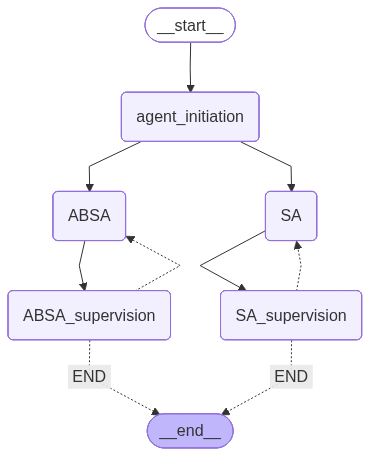

In [5]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
def run_absa_for_review(review_text: str):
    """Run your ABSA LangGraph pipeline on a single review."""
    try:
        # Create the initial state dynamically for each review
        state = graph_4.ABSAState(
            review = review_text,
            absa_agent = dspy.ChainOfThought(graph_4.ABSA_Do),
            absa_supervision_agent = dspy.ChainOfThought(graph_4.ABSA_Supervise),
            absa_fields = [],
            absa_decision = "",
            absa_fields_rationale = "",
            absa_fields_counter = 0,


            sa_agent = dspy.ChainOfThought(graph_4.Overall_Do),
            sa_supervision_agent = dspy.ChainOfThought(graph_4.Overall_Supervise),
            overall_sentiment = "",
            overall_sentiment_decision = "",
            overall_sentiment_rationale = "",
            overall_sentiment_counter = 0,
        )

        # Run the graph
        result = app.invoke(state, {"recursion_limit": 100})

        # Extract only the relevant outputs
        return {
            "absa_fields": result.get("absa_fields", []),
            "overall_sentiment": result.get("overall_sentiment", ""),
            "absa_decision": result.get("absa_decision", ""),
        }

    except Exception as e:
        print(f"Error for review: {review_text[:25]}... -> {e}")
        return {
            "absa_fields": [],
            "overall_sentiment": "error",
            "absa_decision": "",
        }

In [7]:
df4 = pd.read_excel('../data/1000_annotated_sample_final.xlsx')
df4 = df4.drop(columns=(['Unnamed: 0', 'flag']))
df4.shape

(1000, 12)

In [47]:
# res4 = run_absa_for_review(review_text=df4.loc[0, 'text'])

In [48]:
# print(res4['absa_fields'])

In [21]:
df4["absa_results"] = df4["text"].progress_apply(run_absa_for_review)

df4["absa_fields"] = df4["absa_results"].apply(lambda x: x["absa_fields"])
df4["overall_sentiment"] = df4["absa_results"].apply(lambda x: x["overall_sentiment"])

  0%|          | 0/1000 [00:00<?, ?it/s]

node_initiation
node_initiation


  0%|          | 3/1000 [00:34<3:12:01, 11.56s/it]

node_initiation


  0%|          | 4/1000 [00:53<3:52:25, 14.00s/it]

...

100%|█████████▉| 999/1000 [5:16:35<00:24, 24.22s/it]

node_initiation


100%|██████████| 1000/1000 [5:16:54<00:00, 22.69s/it]

node_initiation


100%|██████████| 1000/1000 [5:17:17<00:00, 19.04s/it]


In [22]:
df4.to_excel('1000_annotated_sample_final_graph_4.xlsx')

# Validation results

In [ ]:
df1 = pd.read_excel("../results/1000_annotated_sample_final_graph_1.xlsx")
df2 = pd.read_excel("../results/1000_annotated_sample_final_graph_2.xlsx")
df3 = pd.read_excel("../results/1000_annotated_sample_final_graph_3.xlsx")
df4 = pd.read_excel("../results/1000_annotated_sample_final_graph_4.xlsx")


df1 = df1.add_suffix('_graph_1')
df2 = df2.add_suffix('_graph_2')
df3 = df3.add_suffix('_graph_3')
df4 = df4.add_suffix('_graph_4')


merged_df = pd.concat([df1, df2, df3, df4], axis=1)
merged_df.head(2)

,Unnamed: 0_graph_1,place_id_graph_1,author_graph_1,rating_graph_1,date_graph_1,text_graph_1,place_name_graph_1,index_graph_1,date_parsed_graph_1,ABSA_manual_graph_1,...,place_name_graph_4,index_graph_4,date_parsed_graph_4,ABSA_manual_graph_4,atepc_json_graph_4,len_manual_graph_4,len_atepc_graph_4,absa_results_graph_4,absa_fields_graph_4,overall_sentiment_graph_4
0,0,ChIJs_LE-WM71moR_c251OO23DM,Edward Russel,1,3 years ago,"Utterly useless team, overpromises and underde...",Crave Cafe & Restaurant,2720,2022-10-11,"{""overall_sentiment"":""negative"",""aspects"":[{""a...",...,Crave Cafe & Restaurant,2720,2022-10-11,"{""overall_sentiment"":""negative"",""aspects"":[{""a...","{'sentence': ""Utterly useless team , overpromi...",1,1,"{'absa_fields': ""[\n {\n 'aspect': '...","[\n {\n 'aspect': 'team',\n '...",negative
1,1,ChIJ7yq6lYXGsGoRXmQH2ld5juI,James Martin,1,Edited 5 years ago,Very very poor i would not recomend anyone use...,Australia Post - Royal Park LPO,29442,2020-10-11,"{""overall_sentiment"":""negative"",""aspects"":[{""a...",...,Australia Post - Royal Park LPO,29442,2020-10-11,"{""overall_sentiment"":""negative"",""aspects"":[{""a...",{'sentence': 'Very very poor i would not recom...,1,1,"{'absa_fields': ""[\n {\n 'aspect': '...","[\n {\n 'aspect': 'staff',\n ...",negative


In [9]:
import spacy
import numpy as np
import pandas as pd
import json
import ast
import re
# Load a large English model with word vectors included
nlp = spacy.load('en_core_web_lg')

def cosine_similarity(word_a: str, word_b: str) -> float:
    vector_a = nlp(word_a).vector
    vector_b = nlp(word_b).vector
    dot_product = np.dot(vector_a, vector_b)
    magnitude_a = np.linalg.norm(vector_a)
    magnitude_b = np.linalg.norm(vector_b)
    return dot_product / (magnitude_a * magnitude_b)

def parse_col1(x):
    if not isinstance(x, str):
        return []
    try:
        return json.loads(x).get("aspects", [])
    except Exception:
        return []

def parse_col2(x):
    if not x:
        return []
    try:
        return ast.literal_eval(x)
    except Exception:
        return x 

def normalize(a):
    return a.lower().strip()

def compare_aspects(aspects1, aspects2):
# print(aspects1, '\n', aspects2)
    matches = 0
    try:
        for a1 in aspects1:
            asp1 = normalize(a1.get("aspect", ""))
            sent1 = normalize(a1.get("sentiment", ""))

            for a2 in aspects2:
                asp2 = normalize(a2.get("aspect", ""))
                sent2 = normalize(a2.get("sentiment", ""))
                
                if cosine_similarity(asp1, asp2) >= 0.65: 
                    if sent1 == sent2:
                        matches += 1
                        break
    except Exception:
        return None
    return matches


def node_nlp_extract_pairs(nlp_text: str) -> str:
    """Extract aspects & sentiments from the NLP-annotated fields."""
    raw = nlp_text
    if not raw:
        aspects = []
        sentiments = []

    try:
        parsed = ast.literal_eval(raw)
    except Exception as e:
        aspects = []
        sentiments = []

    aspects = [str(a).strip() for a in parsed.get("aspect", []) or []]
    labels  = [str(s).strip().lower() for s in parsed.get("sentiment", []) or []]

    allowed = {"positive", "negative", "neutral"}
    items = []
    for a, lab in zip(aspects, labels):
        lab = lab if lab in allowed else "neutral"
        items.append({"aspect": a, "opinion": "", "sentiment": lab})
  
    return items

In [11]:
merged_df["aspects_manual"] = merged_df["ABSA_manual_graph_1"].apply(parse_col1)
merged_df["atepc_json"] = merged_df["atepc_json_graph_1"].apply(node_nlp_extract_pairs)
merged_df["aspects_graph_1"] = merged_df["sentiments_graph_1"].apply(parse_col2)
merged_df["aspects_graph_2"] = merged_df["sentiments_graph_2"].apply(parse_col2)
merged_df["aspects_graph_3"] = merged_df["absa_fields_graph_3"].apply(parse_col2)
merged_df["aspects_graph_4"] = merged_df["absa_fields_graph_4"].apply(parse_col2)

In [37]:
absa_cols = [
    "aspects_manual",
    "atepc_json",
    "aspects_graph_1",
    "aspects_graph_2",
    "aspects_graph_3",
    "aspects_graph_4"
]

n = len(absa_cols)
match_matrix = np.zeros((n, n), dtype=int)

for i in range(n):
    for j in range(n):
        # j = 0
        if i <= j: 
            print(i, ', ', j)
            match_matrix[i, j] = merged_df.apply(
                                                lambda row: compare_aspects(row[absa_cols[i]], row[absa_cols[j]]),
                                                axis=1
                                        ).sum()

0 ,  0


C:\Users\asus\AppData\Local\Temp\ipykernel_20112\2814320960.py:16: RuntimeWarning: invalid value encountered in scalar divide
  return dot_product / (magnitude_a * magnitude_b)


0 ,  1
0 ,  2
0 ,  3
0 ,  4
0 ,  5
1 ,  1
1 ,  2
1 ,  3
1 ,  4
1 ,  5
2 ,  2
2 ,  3
2 ,  4
2 ,  5
3 ,  3
3 ,  4
3 ,  5
4 ,  4
4 ,  5
5 ,  5


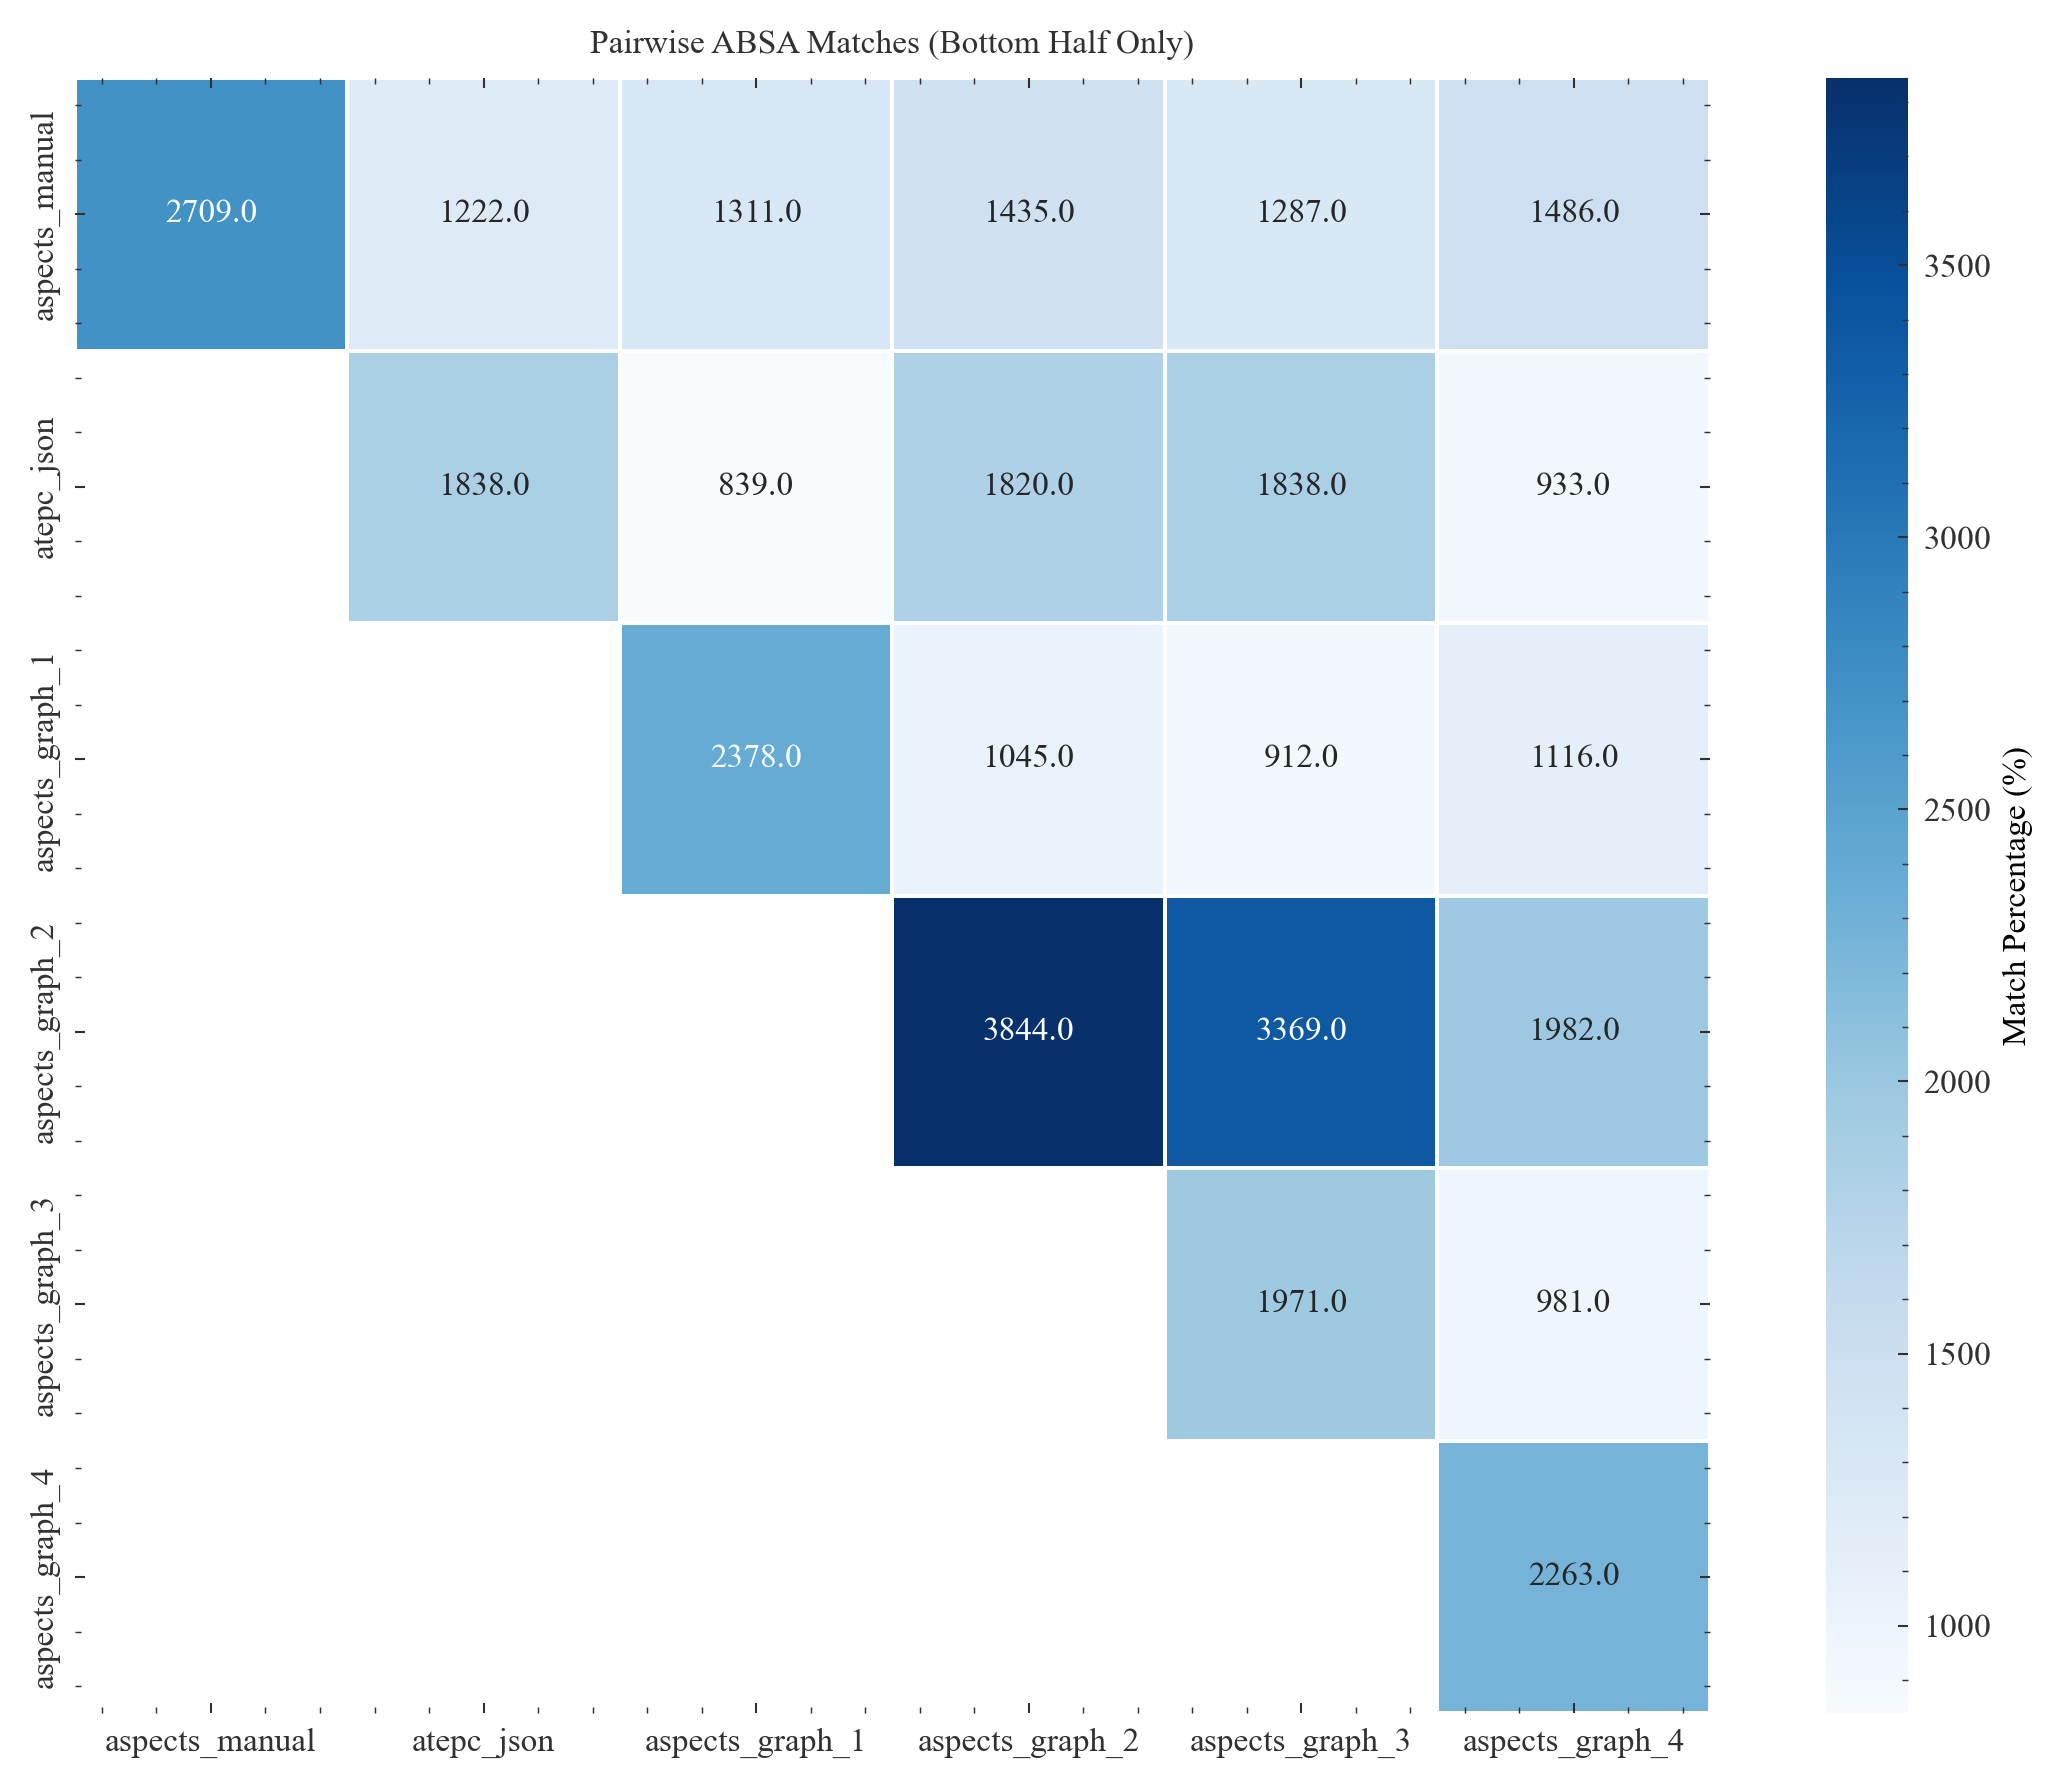

In [ ]:
mask = np.triu(np.ones_like(match_matrix, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(
    match_matrix,
    annot=True,
    fmt='.1f',        
    cmap='Blues',
    mask=~mask,        
    xticklabels=absa_cols,
    yticklabels=absa_cols,
    square=True,       
    linewidths=0.5,
    cbar_kws={"label": "Match Percentage (%)"}
)

plt.title("Pairwise ABSA Matches (Bottom Half Only)")
plt.tight_layout()
plt.show()


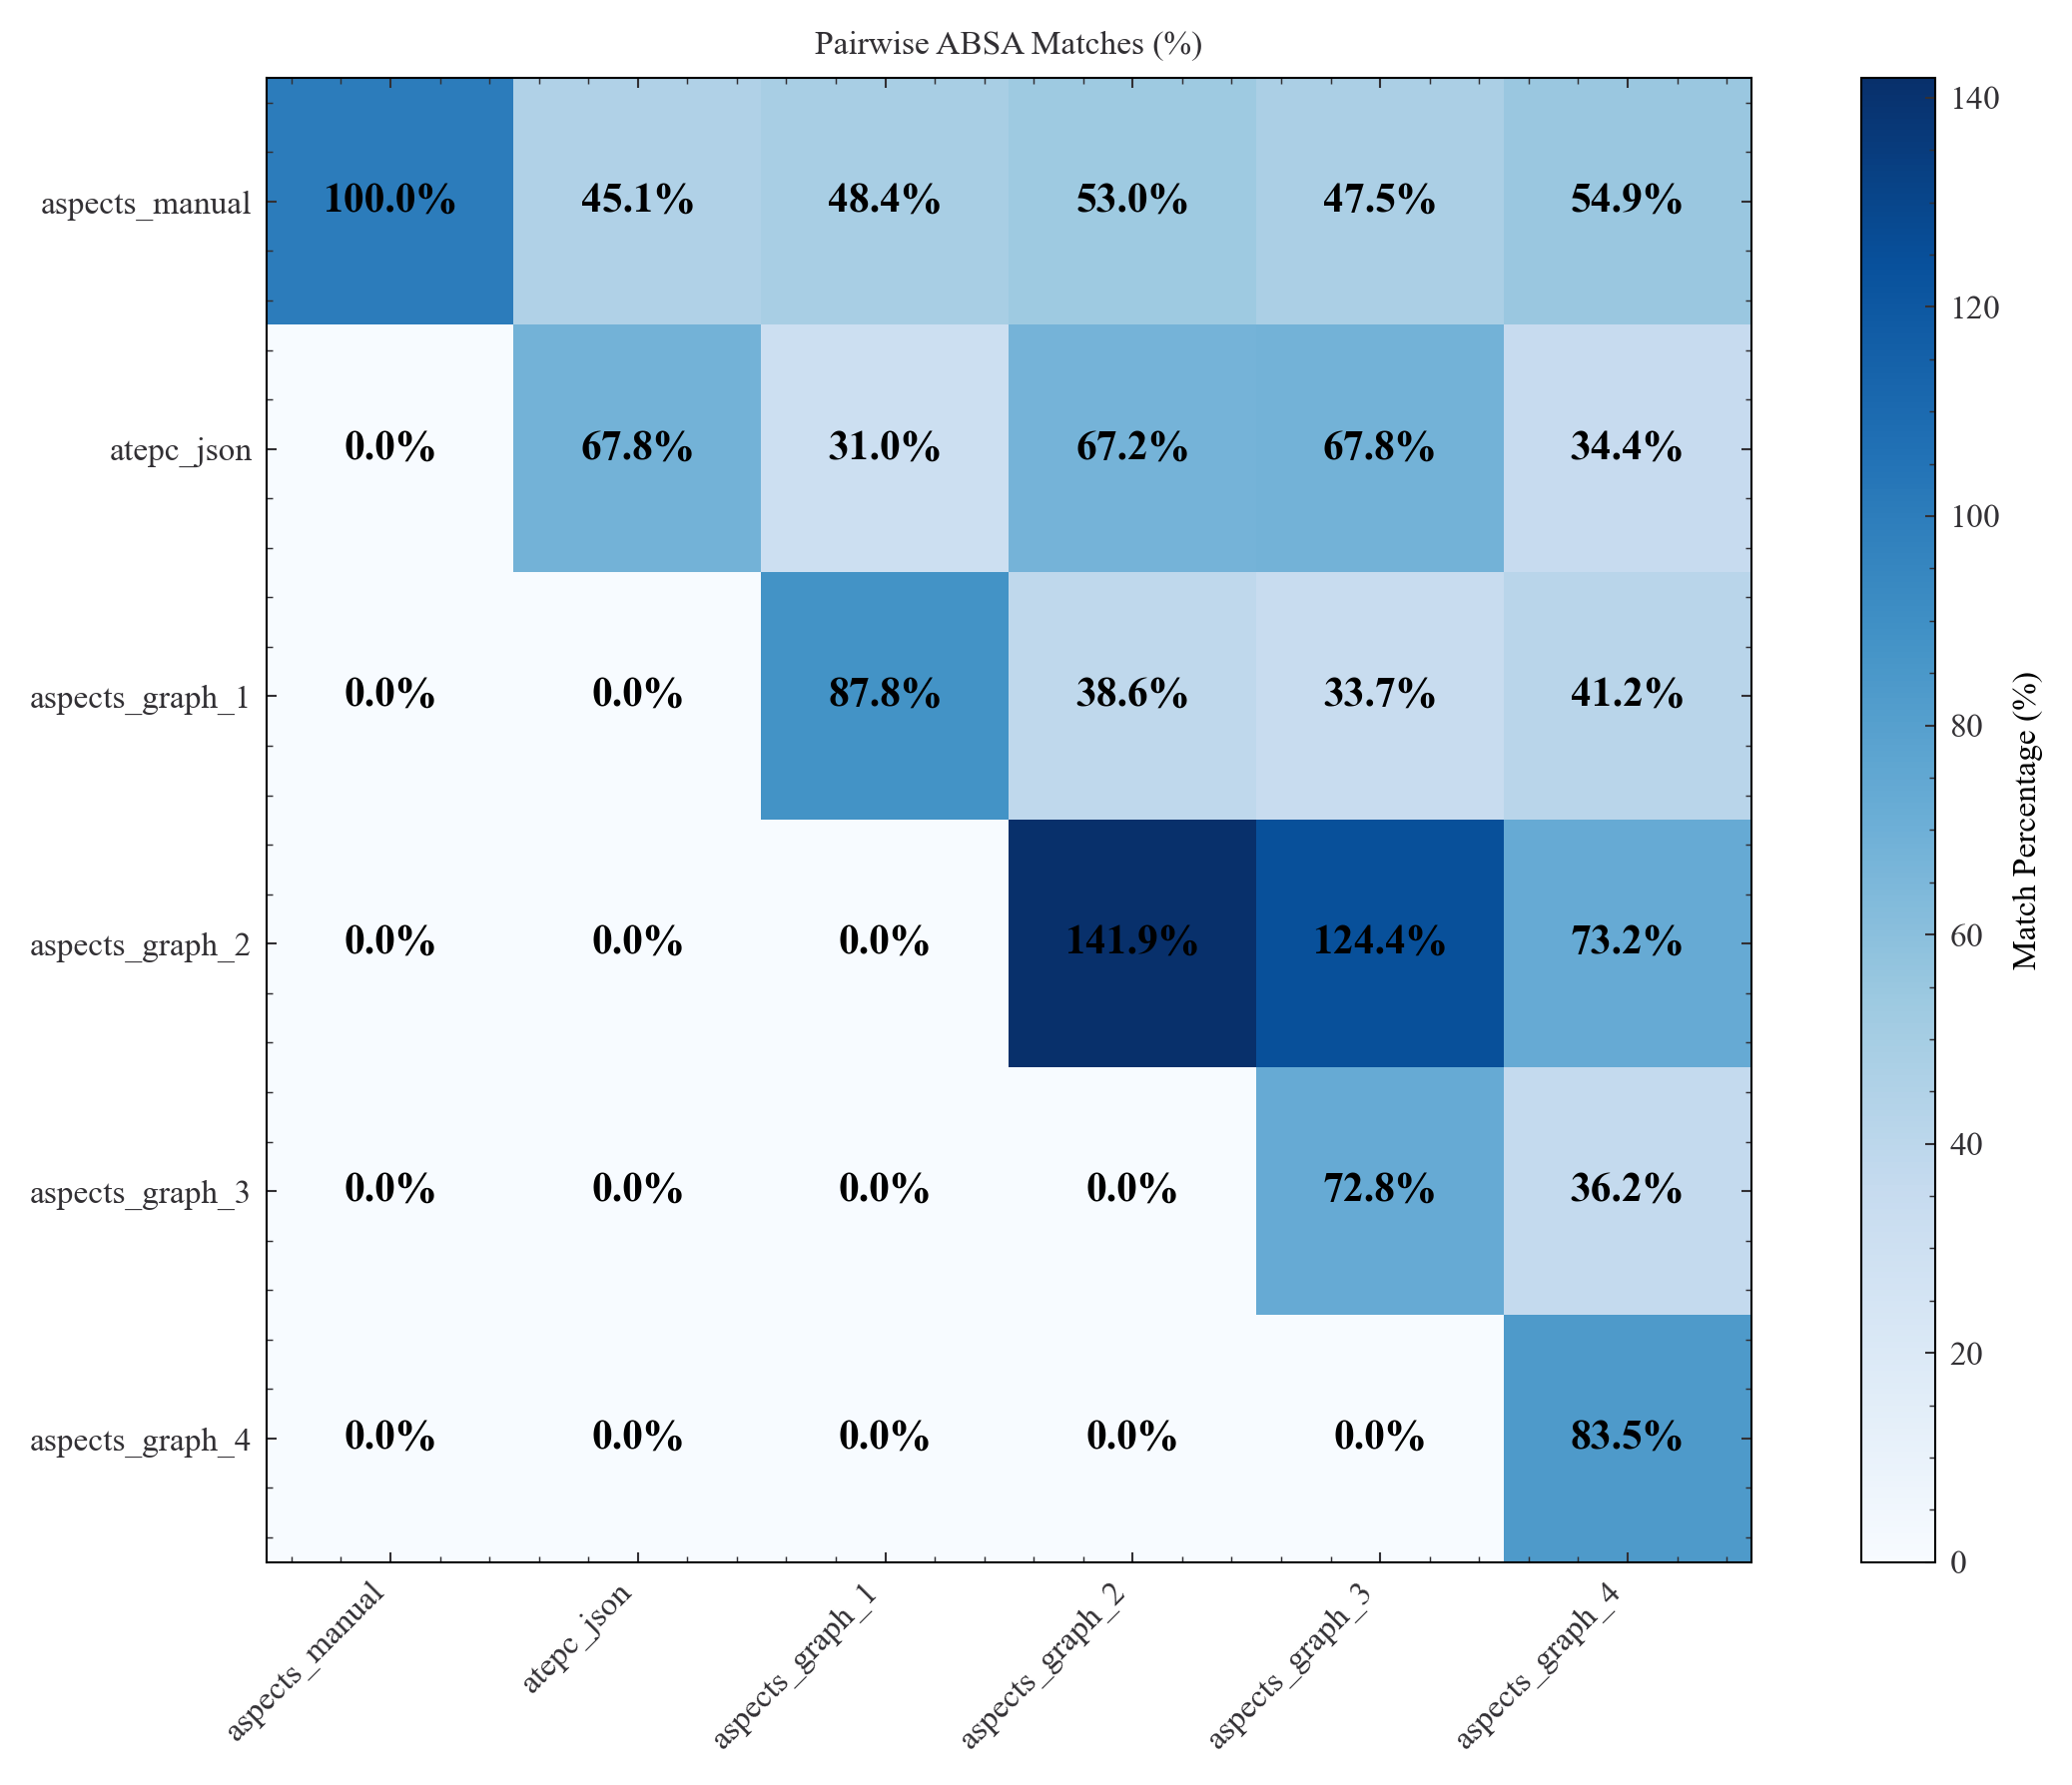

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n = len(absa_cols)
total_rows = match_matrix[0, 0]
percent_matrix = (match_matrix / total_rows) * 100  # convert to percent

plt.figure(figsize=(8, 6))
plt.imshow(percent_matrix, cmap='Blues', interpolation='nearest')
plt.colorbar(label='Match Percentage (%)')

for i in range(n):
    for j in range(n):
        plt.text(j, i, f"{percent_matrix[i, j]:.1f}%",  # one decimal place
                 ha='center', va='center', color='black', fontsize=10, fontweight='bold')

plt.xticks(range(n), absa_cols, rotation=45, ha='right')
plt.yticks(range(n), absa_cols)
plt.title("Pairwise ABSA Matches (%)")
plt.tight_layout()
plt.show()
